# EE446 - TinyML - Assignment 2

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

2026-08-12 17:17:38.225112: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-12 17:17:38.279223: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-12 17:17:38.538124: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-12 17:17:38.538169: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-12 17:17:38.539321: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

## Reading Data

In [2]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [3]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [4]:
data.drop(columns=['land', 'urgent', 'numfailedlogins', 'numoutboundcmds'], inplace=True)

##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [5]:
data['attack'] = data['attack'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

In [6]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [7]:
label_encoder = LabelEncoder()

columns_to_encode = ['protocoltype', 'service', 'flag', 'attack']

for column in columns_to_encode:
    data[column] = label_encoder.fit_transform(data[column])

In [8]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [9]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

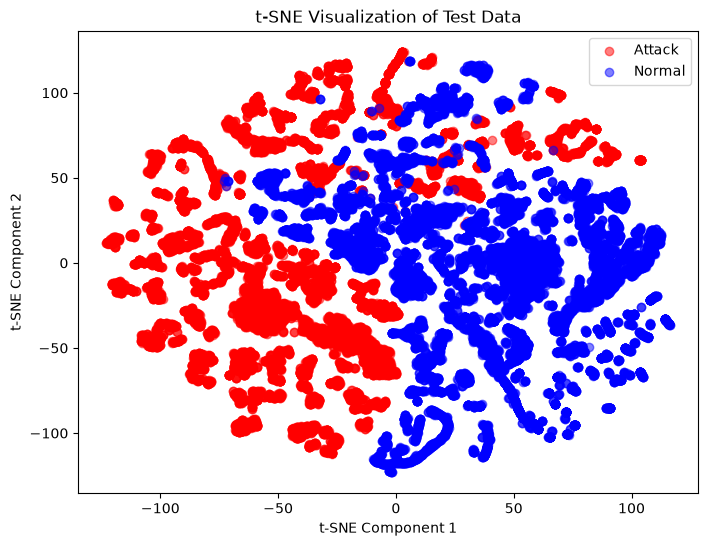

In [10]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_test)

y_plot = y_test.flatten()

plt.figure(figsize=(8, 6))

plt.scatter(
    X_tsne[y_plot == 0, 0],
    X_tsne[y_plot == 0, 1],
    c='red',
    label='Attack',
    alpha=0.5
)

plt.scatter(
    X_tsne[y_plot == 1, 0],
    X_tsne[y_plot == 1, 1],
    c='blue',
    label='Normal',
    alpha=0.5
)

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Visualization of Test Data')
plt.legend()
plt.show()

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

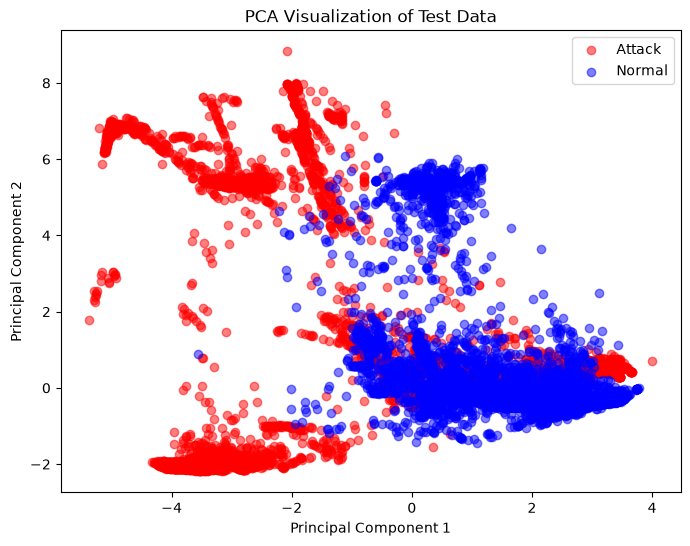

In [11]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

y_plot = y_test.flatten()

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[y_plot == 0, 0],
    X_pca[y_plot == 0, 1],
    c='red',
    label='Attack',
    alpha=0.5
)

plt.scatter(
    X_pca[y_plot == 1, 0],
    X_pca[y_plot == 1, 1],
    c='blue',
    label='Normal',
    alpha=0.5
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Test Data')
plt.legend()
plt.show()

##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

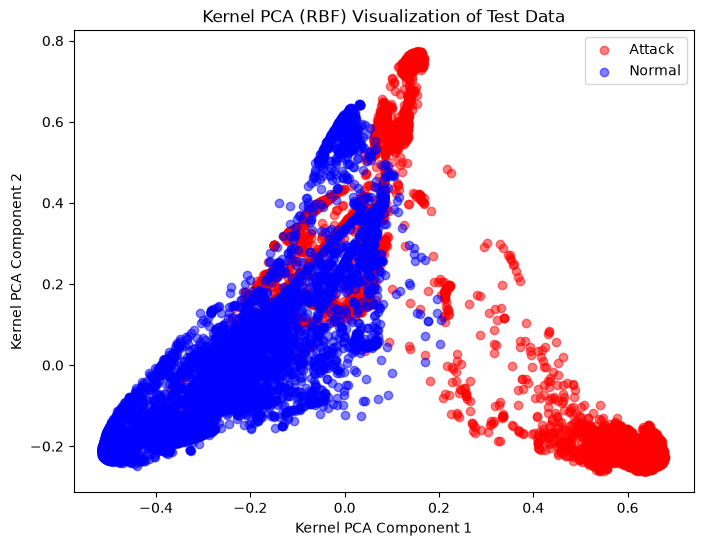

In [12]:
from sklearn.decomposition import KernelPCA
kernel_pca = KernelPCA(n_components=2, kernel='rbf')
X_kpca = kernel_pca.fit_transform(X_test)

y_plot = y_test.flatten()

plt.figure(figsize=(8, 6))

plt.scatter(
    X_kpca[y_plot == 0, 0],
    X_kpca[y_plot == 0, 1],
    c='red',
    label='Attack',
    alpha=0.5
)

plt.scatter(
    X_kpca[y_plot == 1, 0],
    X_kpca[y_plot == 1, 1],
    c='blue',
    label='Normal',
    alpha=0.5
)

plt.xlabel('Kernel PCA Component 1')
plt.ylabel('Kernel PCA Component 2')
plt.title('Kernel PCA (RBF) Visualization of Test Data')
plt.legend()
plt.show()

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure that the output layer contains one neuron with sigmoid activation.

In [13]:
# Define the DNN model
base_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

base_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                2496      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 5121 (20.00 KB)
Trainable params: 5121 (20.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [14]:
base_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = base_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
2520/2520 [==============================] - 11s 4ms/step - loss: 0.0282 - accuracy: 0.9913 - val_loss: 0.0223 - val_accuracy: 0.9962
Epoch 2/20
2520/2520 [==============================] - 9s 3ms/step - loss: 0.0096 - accuracy: 0.9964 - val_loss: 0.0080 - val_accuracy: 0.9971
Epoch 3/20
2520/2520 [==============================] - 8s 3ms/step - loss: 0.0074 - accuracy: 0.9972 - val_loss: 0.0072 - val_accuracy: 0.9974
Epoch 4/20
2520/2520 [==============================] - 7s 3ms/step - loss: 0.0067 - accuracy: 0.9975 - val_loss: 0.0086 - val_accuracy: 0.9980
Epoch 5/20
2520/2520 [==============================] - 6s 2ms/step - loss: 0.0058 - accuracy: 0.9979 - val_loss: 0.0099 - val_accuracy: 0.9977
Epoch 6/20
2520/2520 [==============================] - 5s 2ms/step - loss: 0.0049 - accuracy: 0.9979 - val_loss: 0.0153 - val_accuracy: 0.9976
Epoch 7/20
2520/2520 [==============================] - 5s 2ms/step - loss: 0.0052 - accuracy: 0.9983 - val_loss: 0.0177 - val_accuracy

##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

788/788 [==============================] - 2s 2ms/step
Classification Report:
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00     11696
      Normal       1.00      1.00      1.00     13499

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Confusion Matrix:
[[11678    18]
 [   21 13478]]


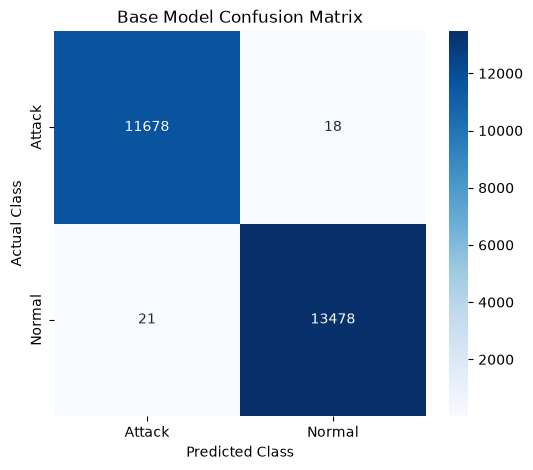

In [15]:
y_pred_prob = base_model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(
    y_test.flatten(),
    y_pred.flatten(),
    target_names=['Attack', 'Normal']
))

print("Confusion Matrix:")
cm = confusion_matrix(y_test.flatten(), y_pred.flatten())
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Attack', 'Normal'],
    yticklabels=['Attack', 'Normal']
)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Base Model Confusion Matrix')
plt.show()

In [16]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement full-integer INT8 post-training quantization on the base_model. Use a representative dataset from X_train to calibrate the activation ranges. Configure the converter to use INT8 operators with INT8 input and output tensors. Designate the resulting quantized model as tflite_quant_model.

In [17]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

# Representative dataset used to calibrate activation ranges
def representative_dataset():
    for i in range(1000):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

# Create TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(base_model)

# Enable post-training quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Set representative dataset
converter.representative_dataset = representative_dataset

# Require full integer INT8 operations
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

# Set model input and output to INT8
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Convert model
tflite_quant_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmp5ojnn_5m/assets


INFO:tensorflow:Assets written to: /tmp/tmp5ojnn_5m/assets
2026-08-12 17:21:53.828590: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-08-12 17:21:53.828646: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-08-12 17:21:53.830077: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp5ojnn_5m
2026-08-12 17:21:53.831200: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-08-12 17:21:53.831213: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp5ojnn_5m
2026-08-12 17:21:53.835712: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-08-12 17:21:53.836502: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-08-12 17:21:53.879318: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

In [18]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 100.01 KB
Quantized model size: 8.24 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

Input scale: 0.20839233696460724
Input zero point: -89
Output scale: 0.00390625
Output zero point: -128


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


INT8 Quantized Model Classification Report:
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00     11696
      Normal       1.00      1.00      1.00     13499

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

INT8 Quantized Model Confusion Matrix:
[[11680    16]
 [   24 13475]]


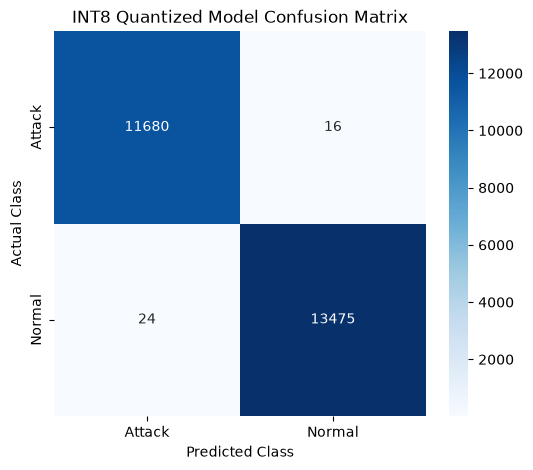

In [19]:
# Create TFLite interpreter
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()

# Get input/output tensor information
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale, input_zero_point = input_details[0]['quantization']
output_scale, output_zero_point = output_details[0]['quantization']

print("Input scale:", input_scale)
print("Input zero point:", input_zero_point)
print("Output scale:", output_scale)
print("Output zero point:", output_zero_point)

y_pred_quant = []

for sample in X_test:

    # Quantize input using the input tensor scale and zero point
    quantized_input = np.round(
        sample / input_scale + input_zero_point
    )

    # Clip to valid INT8 range
    quantized_input = np.clip(
        quantized_input,
        -128,
        127
    ).astype(np.int8)

    # Add batch dimension
    quantized_input = np.expand_dims(quantized_input, axis=0)

    # Run inference
    interpreter.set_tensor(
        input_details[0]['index'],
        quantized_input
    )

    interpreter.invoke()

    # Get quantized output
    quantized_output = interpreter.get_tensor(
        output_details[0]['index']
    )[0][0]

    # Dequantize output
    output = (
        quantized_output - output_zero_point
    ) * output_scale

    # Sigmoid output threshold
    predicted_class = 1 if output >= 0.5 else 0

    y_pred_quant.append(predicted_class)

y_pred_quant = np.array(y_pred_quant)

# Classification report
print("INT8 Quantized Model Classification Report:")
print(classification_report(
    y_test.flatten(),
    y_pred_quant,
    target_names=['Attack', 'Normal']
))

# Confusion matrix
cm_quant = confusion_matrix(
    y_test.flatten(),
    y_pred_quant
)

print("INT8 Quantized Model Confusion Matrix:")
print(cm_quant)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_quant,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Attack', 'Normal'],
    yticklabels=['Attack', 'Normal']
)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('INT8 Quantized Model Confusion Matrix')
plt.show()

## Converting tflite_quant_model to C and creating the header file

In [20]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [21]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [22]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

Xtest = X_test[0:5,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 5;
const unsigned int X_test_dim2 = 38;

const float X_test[5][38] = {
    -0.11024922321249885, -0.12470615670462065, -0.44208308523109213, 
    0.7511112872365361, -0.00772663783792633, -0.004698563737702671, 
    -0.08948642202040107, -0.09507567152556495, 1.2356940323701657, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.6297154656206392, -0.17536713140262664, -0.45801941532601853, 
    -0.4753367403414093, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, 0.12576845924997587, 
    -1.7151105233574202, 1.2587542737799418, 1.0664013456654926, 
    -0.43907816809041417, -0.22129373914817005, 0.155090881452997, 
    -0.4596686265796899, -0.5799942796747285, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.11024922321

In [23]:
ytest=y_test[0:5]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 5;
const unsigned int y_test_dim2 = 1;

const uint8_t y_test[5][1] = {
    1, 1, 0, 0, 0
};



In [24]:
# Generate the next 10 test samples, excluding the first five
Xtest_new = X_test[5:15, :]

print(c_writer.create_array(
    Xtest_new,
    "float",
    "X_test_new"
))

const unsigned int X_test_new_dim1 = 10;
const unsigned int X_test_new_dim2 = 38;

const float X_test_new[10][38] = {
    -0.11024922321249885, 2.219311849644404, -1.1761894520278895, 
    0.7511112872365361, -0.007757300624891102, -0.004911432701538836, 
    -0.08948642202040107, -0.09507567152556495, -0.8092618187059747, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.7257784945454897, -0.3405754870548312, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, 3.4741184775599305, 
    0.7343425609306344, 1.2406878020363448, 1.0441270303429973, 
    -0.3861460041139426, -0.4801968475158174, -0.28910340026287856, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.11

In [25]:
# Actual labels for the next 10 test samples
ytest_new = y_test[5:15]

print(c_writer.create_array(
    ytest_new,
    "uint8_t",
    "y_test_new"
))

const unsigned int y_test_new_dim1 = 10;
const unsigned int y_test_new_dim2 = 1;

const uint8_t y_test_new[10][1] = {
    1, 1, 0, 1, 1, 0, 1, 1, 1, 1
};

